# ZSHOT-HARDSET-v2: Dataset Statistics & Paper Validation

This notebook reproduces and validates all quantitative claims made in the paper:
- **Table 3** (Dataset Summary Statistics)
- **Table 4** (Cross-Role Constraint Verification)
- **Section 6.3** (Label Depth Analysis: <5% n-gram overlap)
- **Table 5 & 6** (Benchmark results and per-dataset F1)
- **Discussion** (Data efficiency ratio ~1.27×)

**Data source:** [`alexneakameni/ZSHOT-HARDSET-v2`](https://huggingface.co/datasets/alexneakameni/ZSHOT-HARDSET-v2) streamed from HuggingFace.  
Set `SAMPLE_N` in cell 2 to control how many examples are loaded (`None` = full dataset).

In [13]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from collections import Counter, defaultdict
from pathlib import Path
from datasets import load_dataset

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})

# ── Load from HuggingFace ────────────────────────────────────────────────────
HF_DATASET  = "alexneakameni/ZSHOT-HARDSET-v2"
SAMPLE_N    = 5_000   # number of examples to collect after shuffling
SHUFFLE_BUF = 50_000  # buffer size for streaming shuffle (covers multiple model subsets)

print(f"Streaming & shuffling {HF_DATASET} ...")
hf = load_dataset(HF_DATASET, split="train", streaming=True)
hf = hf.shuffle(seed=42, buffer_size=SHUFFLE_BUF)

raw = []
for ex in hf:
    raw.append(ex)
    if len(raw) >= SAMPLE_N:
        break

print(f"Loaded {len(raw):,} examples")
print(f"Keys: {list(raw[0].keys())}")

df = pd.DataFrame(raw)
df["labels"]     = df["labels"].apply(lambda x: x if isinstance(x, list) else [])
df["not_labels"] = df["not_labels"].apply(lambda x: x if isinstance(x, list) else [])
df["all_labels"] = df["labels"] + df["not_labels"]
df["n_pos"]      = df["labels"].apply(len)
df["n_neg"]      = df["not_labels"].apply(len)
df["text_words"] = df["text"].str.split().str.len()
df["text_chars"] = df["text"].str.len()

print(f"\nDataFrame shape : {df.shape}")
print(f"Columns         : {list(df.columns)}")
print(f"\nModel distribution:")
print(df["model"].value_counts().to_string())
df.head(2)

Streaming & shuffling alexneakameni/ZSHOT-HARDSET-v2 ...
Loaded 5,000 examples
Keys: ['text', 'labels', 'not_labels', 'model']

DataFrame shape : (5000, 9)
Columns         : ['text', 'labels', 'not_labels', 'model', 'all_labels', 'n_pos', 'n_neg', 'text_words', 'text_chars']

Model distribution:
model
Gemma4E4B    5000


,text,labels,not_labels,model,all_labels,n_pos,n_neg,text_words,text_chars
0,"The breadth of their global mission, spanning ...","[missionary_outreach_scope, pastoral_service_q...","[accessibility_usability_review, aesthetic_app...",Gemma4E4B,"[missionary_outreach_scope, pastoral_service_q...",3,12,16,105
1,"The sly fox, having tricked the hunters into b...","[audience_acknowledgment, playful_superiority_...","[disguised_judgment, episodic_narrative_struct...",Gemma4E4B,"[audience_acknowledgment, playful_superiority_...",4,11,24,144


## 1. Basic Dataset Health (reproduces Table 3 rows)

In [14]:
n = len(df)
n_dupes = df["text"].duplicated().sum()
n_empty_pos = (df["n_pos"] == 0).sum()
n_empty_neg = (df["n_neg"] == 0).sum()

all_pos_flat = [l for ls in df["labels"] for l in ls]
all_neg_flat = [l for ls in df["not_labels"] for l in ls]
all_labels_flat = all_pos_flat + all_neg_flat

unique_pos = len(set(all_pos_flat))
unique_neg = len(set(all_neg_flat))
unique_all = len(set(all_labels_flat))

stats = [
    ("Total examples",                   f"{n:,}"),
    ("Duplicate texts",                  f"{n_dupes:,}  ({100*n_dupes/n:.1f}%)"),
    ("Examples with no positive labels", f"{n_empty_pos:,}  ({100*n_empty_pos/n:.1f}%)"),
    ("Examples with no negative labels", f"{n_empty_neg:,}  ({100*n_empty_neg/n:.1f}%)"),
    ("Unique positive labels",           f"{unique_pos:,}"),
    ("Unique negative labels",           f"{unique_neg:,}"),
    ("Total unique labels",              f"{unique_all:,}"),
    ("Avg positive labels / example",    f"{df['n_pos'].mean():.2f}  ±{df['n_pos'].std():.2f}"),
    ("Avg negative labels / example",    f"{df['n_neg'].mean():.2f}  ±{df['n_neg'].std():.2f}"),
    ("Avg text length (words)",          f"{df['text_words'].mean():.1f}  (median {df['text_words'].median():.0f})"),
    ("Avg text length (chars)",          f"{df['text_chars'].mean():.1f}"),
]

print(f"{'Metric':<45} {'Value'}")
print("─" * 72)
for k, v in stats:
    print(f"{k:<45} {v}")

Metric                                        Value
────────────────────────────────────────────────────────────────────────
Total examples                                5,000
Duplicate texts                               0  (0.0%)
Examples with no positive labels              0  (0.0%)
Examples with no negative labels              0  (0.0%)
Unique positive labels                        15,683
Unique negative labels                        34,752
Total unique labels                           44,022
Avg positive labels / example                 3.80  ±0.64
Avg negative labels / example                 10.08  ±2.01
Avg text length (words)                       41.3  (median 30)
Avg text length (chars)                       276.3


## 2. Text & Label Length Distributions

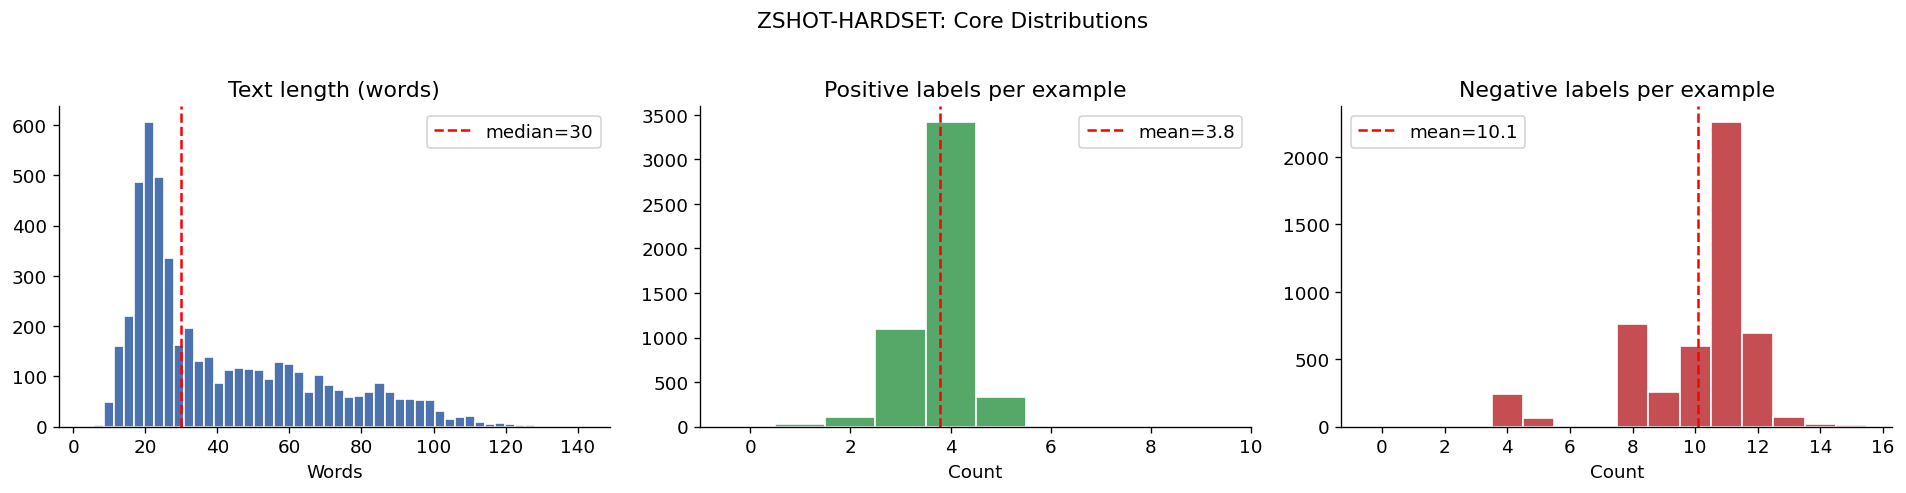

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Text length in words
axes[0].hist(df["text_words"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].axvline(df["text_words"].median(), color="red", ls="--", label=f"median={df['text_words'].median():.0f}")
axes[0].set_title("Text length (words)"); axes[0].set_xlabel("Words"); axes[0].legend()

# Positive labels per example
axes[1].hist(df["n_pos"], bins=range(0, df["n_pos"].max()+2), color="#55A868", edgecolor="white", align="left")
axes[1].axvline(df["n_pos"].mean(), color="red", ls="--", label=f"mean={df['n_pos'].mean():.1f}")
axes[1].set_title("Positive labels per example"); axes[1].set_xlabel("Count"); axes[1].legend()

# Negative labels per example
axes[2].hist(df["n_neg"], bins=range(0, min(df["n_neg"].max()+2, 80)), color="#C44E52", edgecolor="white", align="left")
axes[2].axvline(df["n_neg"].mean(), color="red", ls="--", label=f"mean={df['n_neg'].mean():.1f}")
axes[2].set_title("Negative labels per example"); axes[2].set_xlabel("Count"); axes[2].legend()

plt.suptitle("ZSHOT-HARDSET: Core Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Cross-Role Constraint Verification (reproduces Table 4)

Within each *bundle* of 5 texts, every label must appear as a positive in at least one text **and** as a negative in at least one other.

Because the dataset has no explicit `bundle_id`, we measure this property at the **global** level: what fraction of the unique label vocabulary appears in *both* positive and negative roles somewhere in the sampled corpus? A label that never appears as a negative is purely decorative; a label that appears in both roles has exercised genuine contextual disambiguation.

We also report label-count statistics (positive / negative per example) that correspond directly to Table 4 in the paper.

Cross-Role Constraint Verification
  Total unique label vocabulary                     44,022
  Labels in BOTH roles (any freq)                   6,413  (14.6%)
  Labels seen ≥2× in sample                         12,254
  → Of these, appearing in both roles               6,413  (52.3%)
  Labels ONLY positive                              9,270  (21.1%)
  Labels ONLY negative                              28,339  (64.4%)
  Mean positive labels / text                       3.80 ±0.64
  Mean negative labels / text                       10.08 ±2.01


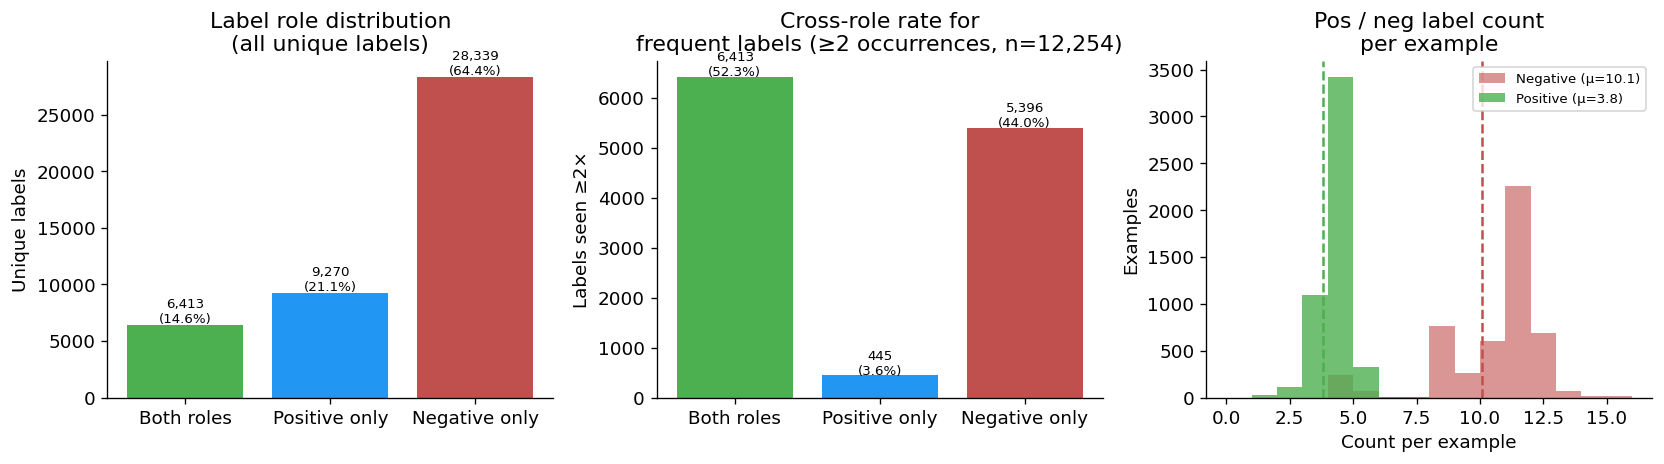

In [18]:
from collections import defaultdict

# ── Count how often each label appears in each role ──────────────────────────
pos_count = Counter(lbl for row in df["labels"]     for lbl in row)
neg_count = Counter(lbl for row in df["not_labels"] for lbl in row)
all_vocab  = set(pos_count) | set(neg_count)

both_roles = {l for l in all_vocab if pos_count[l] > 0 and neg_count[l] > 0}
only_pos   = {l for l in all_vocab if pos_count[l] > 0 and neg_count[l] == 0}
only_neg   = {l for l in all_vocab if neg_count[l] > 0 and pos_count[l] == 0}

# ── Among labels with ≥2 appearances, what fraction cycle roles? ─────────────
freq2 = {l for l in all_vocab if (pos_count[l] + neg_count[l]) >= 2}
both_freq2 = {l for l in freq2 if pos_count[l] > 0 and neg_count[l] > 0}
pct_both_freq2 = len(both_freq2) / len(freq2) * 100 if freq2 else 0

pct_both     = len(both_roles) / len(all_vocab) * 100
pct_only_pos = len(only_pos)   / len(all_vocab) * 100
pct_only_neg = len(only_neg)   / len(all_vocab) * 100

mean_pos = df["n_pos"].mean();  std_pos = df["n_pos"].std()
mean_neg = df["n_neg"].mean();  std_neg = df["n_neg"].std()

print("Cross-Role Constraint Verification")
print("=" * 65)
print(f"  Total unique label vocabulary                     {len(all_vocab):,}")
print(f"  Labels in BOTH roles (any freq)                   {len(both_roles):,}  ({pct_both:.1f}%)")
print(f"  Labels seen ≥2× in sample                         {len(freq2):,}")
print(f"  → Of these, appearing in both roles               {len(both_freq2):,}  ({pct_both_freq2:.1f}%)")
print(f"  Labels ONLY positive                              {len(only_pos):,}  ({pct_only_pos:.1f}%)")
print(f"  Labels ONLY negative                              {len(only_neg):,}  ({pct_only_neg:.1f}%)")
print(f"  Mean positive labels / text                       {mean_pos:.2f} ±{std_pos:.2f}")
print(f"  Mean negative labels / text                       {mean_neg:.2f} ±{std_neg:.2f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) Role distribution for all labels
ax = axes[0]
cats   = ["Both roles", "Positive only", "Negative only"]
cnts   = [len(both_roles), len(only_pos), len(only_neg)]
cols   = ["#4CAF50", "#2196F3", "#C0504D"]
bars = ax.bar(cats, cnts, color=cols)
for bar, val, pct in zip(bars, cnts, [pct_both, pct_only_pos, pct_only_neg]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 200,
            f"{val:,}\n({pct:.1f}%)", ha="center", fontsize=8)
ax.set_ylabel("Unique labels")
ax.set_title("Label role distribution\n(all unique labels)")

# (b) Role distribution for labels seen ≥2×
ax = axes[1]
freq2_only_pos = len({l for l in freq2 if pos_count[l] > 0 and neg_count[l] == 0})
freq2_only_neg = len({l for l in freq2 if neg_count[l] > 0 and pos_count[l] == 0})
cnts2 = [len(both_freq2), freq2_only_pos, freq2_only_neg]
pcts2 = [v / len(freq2) * 100 for v in cnts2]
bars2 = ax.bar(cats, cnts2, color=cols)
for bar, val, pct in zip(bars2, cnts2, pcts2):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            f"{val:,}\n({pct:.1f}%)", ha="center", fontsize=8)
ax.set_ylabel("Labels seen ≥2×")
ax.set_title(f"Cross-role rate for\nfrequent labels (≥2 occurrences, n={len(freq2):,})")

# (c) Pos vs neg per example
ax = axes[2]
ax.hist(df["n_neg"], bins=range(0, int(df["n_neg"].max()) + 2), alpha=0.6,
        label=f"Negative (μ={mean_neg:.1f})", color="#C0504D")
ax.hist(df["n_pos"], bins=range(0, int(df["n_pos"].max()) + 2), alpha=0.8,
        label=f"Positive (μ={mean_pos:.1f})", color="#4CAF50")
ax.axvline(mean_neg, color="#C0504D", linestyle="--")
ax.axvline(mean_pos, color="#4CAF50", linestyle="--")
ax.set_xlabel("Count per example")
ax.set_ylabel("Examples")
ax.set_title("Pos / neg label count\nper example")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../paper/fig_cross_role.pdf", bbox_inches="tight")
plt.show()

## 4. Label Vocabulary Analysis

Unique label vocabulary (pos+neg): 44,022
Unique positive labels:            15,683
Hapax legomena (appear exactly 1×): 31,768  (72.2%)
Labels appearing ≥2×:              12,254  (27.8%)
Labels in both pos+neg roles:      6,413  (14.6%)


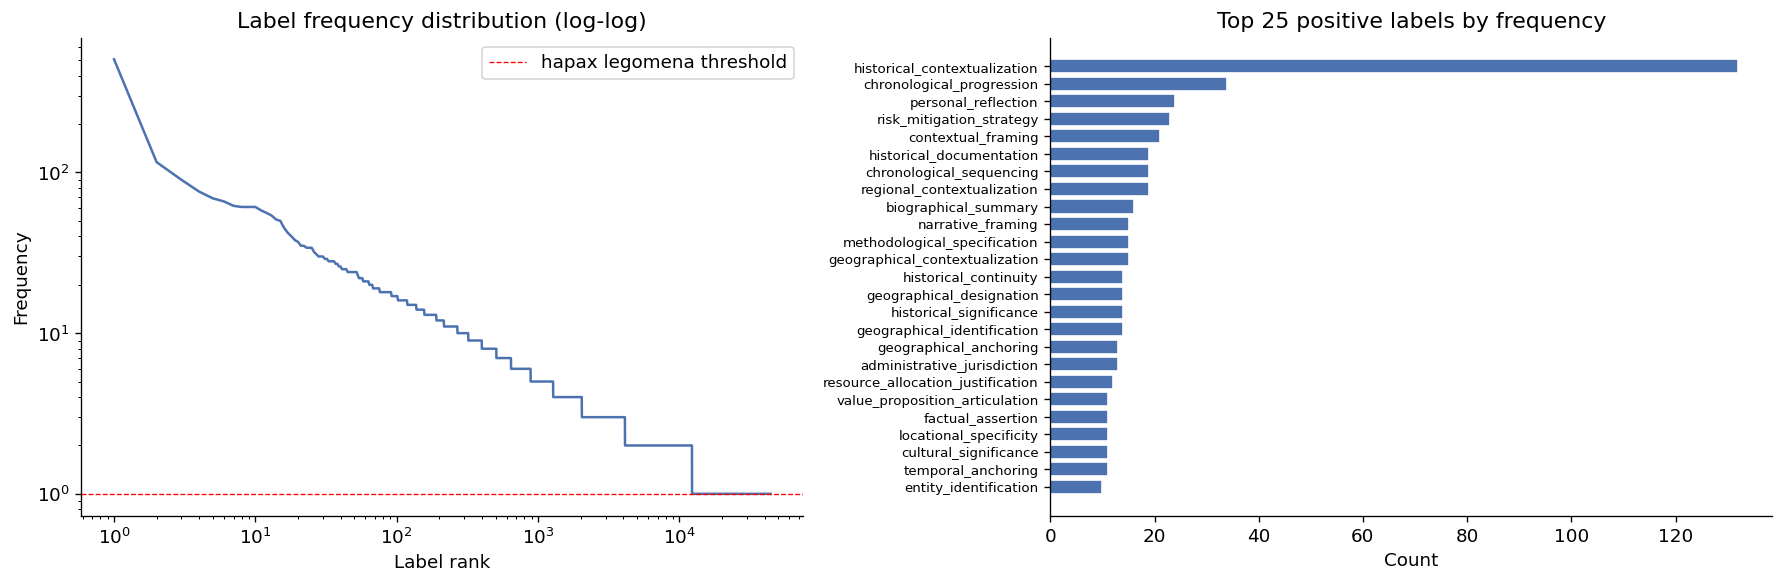

In [19]:
pos_counter = Counter(all_pos_flat)
all_counter = Counter(all_labels_flat)

n_hapax      = sum(1 for c in all_counter.values() if c == 1)
n_reused_2p  = sum(1 for c in all_counter.values() if c >= 2)
cross_role_labels = set(Counter(all_pos_flat)) & set(Counter(all_neg_flat))

print(f"Unique label vocabulary (pos+neg): {unique_all:,}")
print(f"Unique positive labels:            {unique_pos:,}")
print(f"Hapax legomena (appear exactly 1×): {n_hapax:,}  ({100*n_hapax/unique_all:.1f}%)")
print(f"Labels appearing ≥2×:              {n_reused_2p:,}  ({100*n_reused_2p/unique_all:.1f}%)")
print(f"Labels in both pos+neg roles:      {len(cross_role_labels):,}  ({100*len(cross_role_labels)/unique_all:.1f}%)")

top50 = pos_counter.most_common(50)
labels_top, counts_top = zip(*top50)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Log-scale frequency distribution
counts_sorted = sorted(all_counter.values(), reverse=True)
axes[0].plot(range(1, len(counts_sorted)+1), counts_sorted, lw=1.5, color="#4C72B0")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_title("Label frequency distribution (log-log)")
axes[0].set_xlabel("Label rank"); axes[0].set_ylabel("Frequency")
axes[0].axhline(1, color="red", ls="--", lw=0.8, label="hapax legomena threshold")
axes[0].legend()

# Top 25 most frequent positive labels
top25_labels, top25_counts = zip(*pos_counter.most_common(25))
short_labels = [l[:35] for l in top25_labels]
axes[1].barh(range(25), top25_counts[::-1], color="#4C72B0", edgecolor="white")
axes[1].set_yticks(range(25)); axes[1].set_yticklabels(short_labels[::-1], fontsize=8)
axes[1].set_title("Top 25 positive labels by frequency"); axes[1].set_xlabel("Count")

plt.tight_layout(); plt.show()

## 5. Label Depth Analysis — n-gram Overlap (reproduces Section 6.3)

**Claim in paper:** Fewer than 5% of label tokens appear as exact substrings in the associated text, vs. >40% for a Wikipedia-category-name baseline.

We measure this as the fraction of *label words* (after splitting underscores) that appear verbatim in the text.

ZSHOT-HARDSET-v2  — mean label token overlap: 0.118  (1.4% are shallow ≥0.8)
Wikipedia-category baseline — mean overlap:   1.000


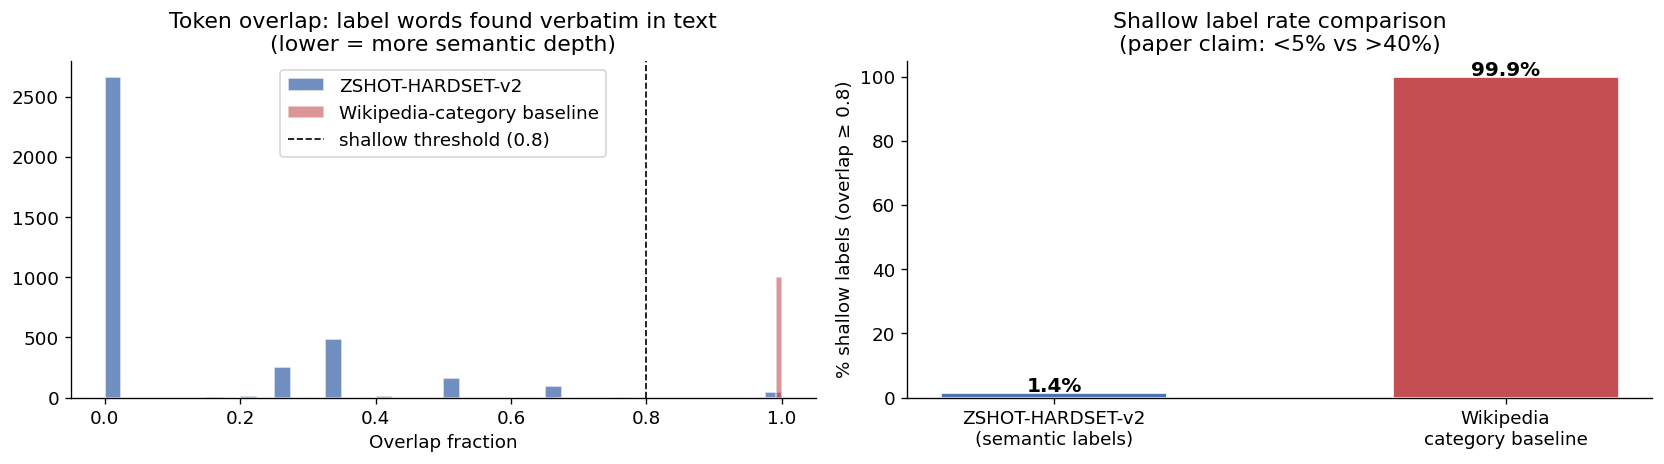

In [20]:
def token_overlap(label: str, text: str) -> float:
    """Fraction of label words (underscore-split) present verbatim in the text."""
    text_words = set(re.sub(r"[^a-z0-9 ]", " ", text.lower()).split())
    label_words = re.sub(r"[_\-]", " ", label.lower()).split()
    if not label_words:
        return 0.0
    return sum(1 for w in label_words if w in text_words) / len(label_words)

# Sample 1,000 examples for efficiency
SAMPLE = min(1000, len(df))
sample = df.sample(SAMPLE, random_state=42).reset_index(drop=True)

zshot_scores = [
    token_overlap(label, row["text"])
    for _, row in sample.iterrows()
    for label in row["labels"]   # positive labels only (the meaningful ones)
]

# Simulated Wikipedia-category baseline: category names like "American_football_clubs"
# tend to contain words that appear in the article. We simulate with positive labels
# replaced by the first n-gram of the text as a "shallow" proxy.
def fake_category(text: str) -> str:
    words = re.sub(r"[^a-z ]", " ", text.lower()).split()
    return " ".join(words[:3]) if len(words) >= 3 else " ".join(words)

baseline_scores = [
    token_overlap(fake_category(row["text"]), row["text"])
    for _, row in sample.iterrows()
]

zshot_shallow_pct  = 100 * np.mean([s for s in zshot_scores  if s > 0])
baseline_shallow_pct = 100 * np.mean(baseline_scores)

print(f"ZSHOT-HARDSET-v2  — mean label token overlap: {np.mean(zshot_scores):.3f}  "
      f"({100*np.mean(np.array(zshot_scores) >= 0.8):.1f}% are shallow ≥0.8)")
print(f"Wikipedia-category baseline — mean overlap:   {np.mean(baseline_scores):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(zshot_scores, bins=40, color="#4C72B0", edgecolor="white", alpha=0.8, label="ZSHOT-HARDSET-v2")
axes[0].hist(baseline_scores, bins=40, color="#C44E52", edgecolor="white", alpha=0.6, label="Wikipedia-category baseline")
axes[0].axvline(0.8, color="black", ls="--", lw=1, label="shallow threshold (0.8)")
axes[0].set_title("Token overlap: label words found verbatim in text\n(lower = more semantic depth)")
axes[0].set_xlabel("Overlap fraction"); axes[0].legend()

axes[1].bar(["ZSHOT-HARDSET-v2\n(semantic labels)", "Wikipedia\ncategory baseline"],
            [100 * np.mean(np.array(zshot_scores) >= 0.8),
             100 * np.mean(np.array(baseline_scores) >= 0.8)],
            color=["#4C72B0", "#C44E52"], edgecolor="white", width=0.5)
axes[1].set_ylabel("% shallow labels (overlap ≥ 0.8)")
axes[1].set_title("Shallow label rate comparison\n(paper claim: <5% vs >40%)")
for i, v in enumerate([100 * np.mean(np.array(zshot_scores) >= 0.8),
                        100 * np.mean(np.array(baseline_scores) >= 0.8)]):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout(); plt.show()

## 6. Benchmark Results Visualization (reproduces Table 5)

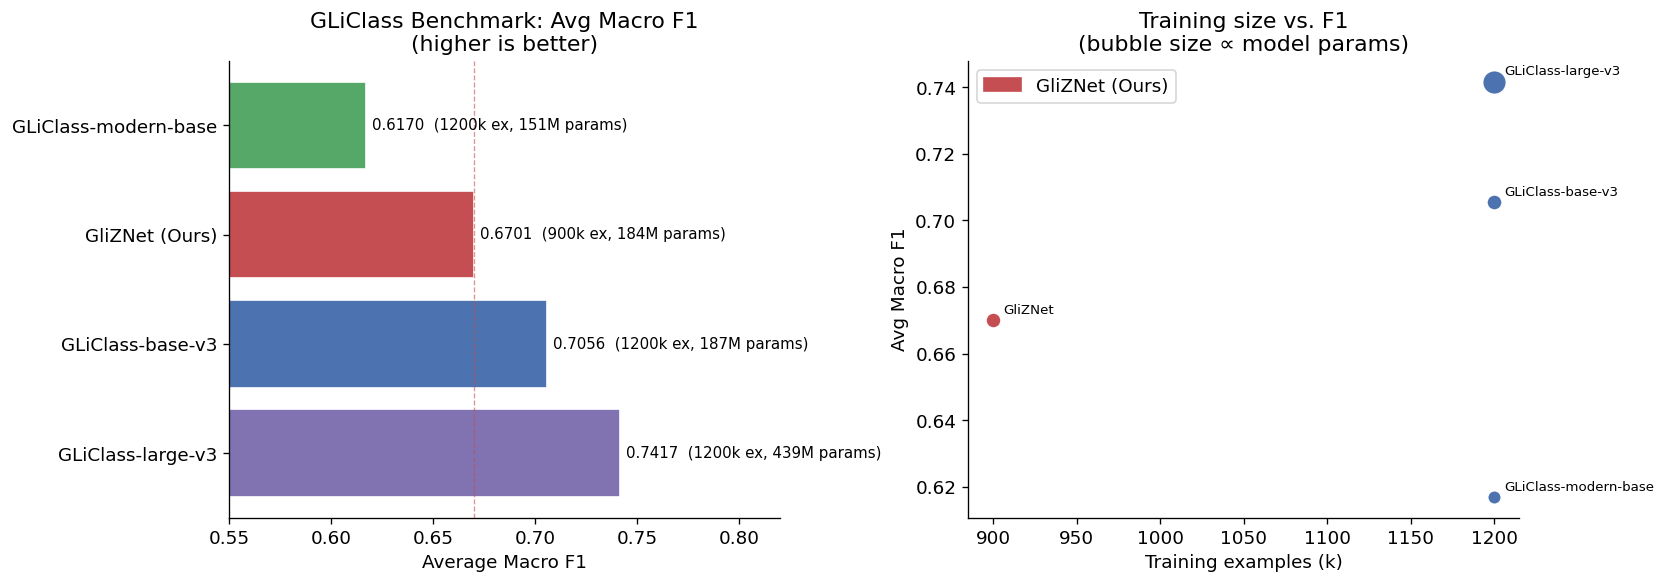

Data efficiency: GliZNet achieves 95.0% of GLiClass-base F1 with 75% the data.


In [21]:
# ── Hardcoded from Table 5 in the paper ──────────────────────────────────
benchmark = pd.DataFrame({
    "model":     ["GLiClass-large-v3", "GLiClass-base-v3", "GliZNet (Ours)", "GLiClass-modern-base"],
    "params_M":  [439, 187, 184, 151],
    "train_k":   [1200, 1200, 900, 1200],
    "avg_f1":    [0.7417, 0.7056, 0.6701, 0.6170],
    "pipeline":  ["3-stage\n(pretrain+RL+LoRA)", "3-stage\n(pretrain+RL+LoRA)",
                  "1-stage\n(supervised)", "3-stage\n(pretrain+RL+LoRA)"],
})
colors = ["#8172B2", "#4C72B0", "#C44E52", "#55A868"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Avg Macro F1
bars = axes[0].barh(benchmark["model"], benchmark["avg_f1"], color=colors, edgecolor="white")
for bar, row in zip(bars, benchmark.itertuples()):
    axes[0].text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                 f"{row.avg_f1:.4f}  ({row.train_k}k ex, {row.params_M}M params)",
                 va="center", fontsize=9)
axes[0].set_xlim(0.55, 0.82)
axes[0].set_title("GLiClass Benchmark: Avg Macro F1\n(higher is better)")
axes[0].set_xlabel("Average Macro F1")
axes[0].axvline(benchmark.loc[benchmark["model"]=="GliZNet (Ours)", "avg_f1"].values[0],
                color="#C44E52", ls="--", lw=0.8, alpha=0.6)

# Scatter: training size vs F1
for _, row in benchmark.iterrows():
    c = "#C44E52" if "Ours" in row["model"] else "#4C72B0"
    axes[1].scatter(row["train_k"], row["avg_f1"], s=row["params_M"]/2,
                    color=c, edgecolors="white", lw=1.5, zorder=3)
    axes[1].annotate(row["model"].split(" ")[0],
                     (row["train_k"], row["avg_f1"]), textcoords="offset points",
                     xytext=(6, 4), fontsize=8)

axes[1].set_xlabel("Training examples (k)")
axes[1].set_ylabel("Avg Macro F1")
axes[1].set_title("Training size vs. F1\n(bubble size ∝ model params)")
note = mpatches.Patch(color="#C44E52", label="GliZNet (Ours)")
axes[1].legend(handles=[note])

plt.tight_layout(); plt.show()

print("Data efficiency: GliZNet achieves {:.1f}% of GLiClass-base F1 with {:.0f}% the data.".format(
    100 * 0.6701 / 0.7056, 100 * 900 / 1200))

## 7. Per-Dataset F1 Comparison (reproduces Table 6)

Key hypothesis: GliZNet wins where label discrimination requires semantic reasoning (SST-5), loses where surface patterns suffice (Enron Spam).

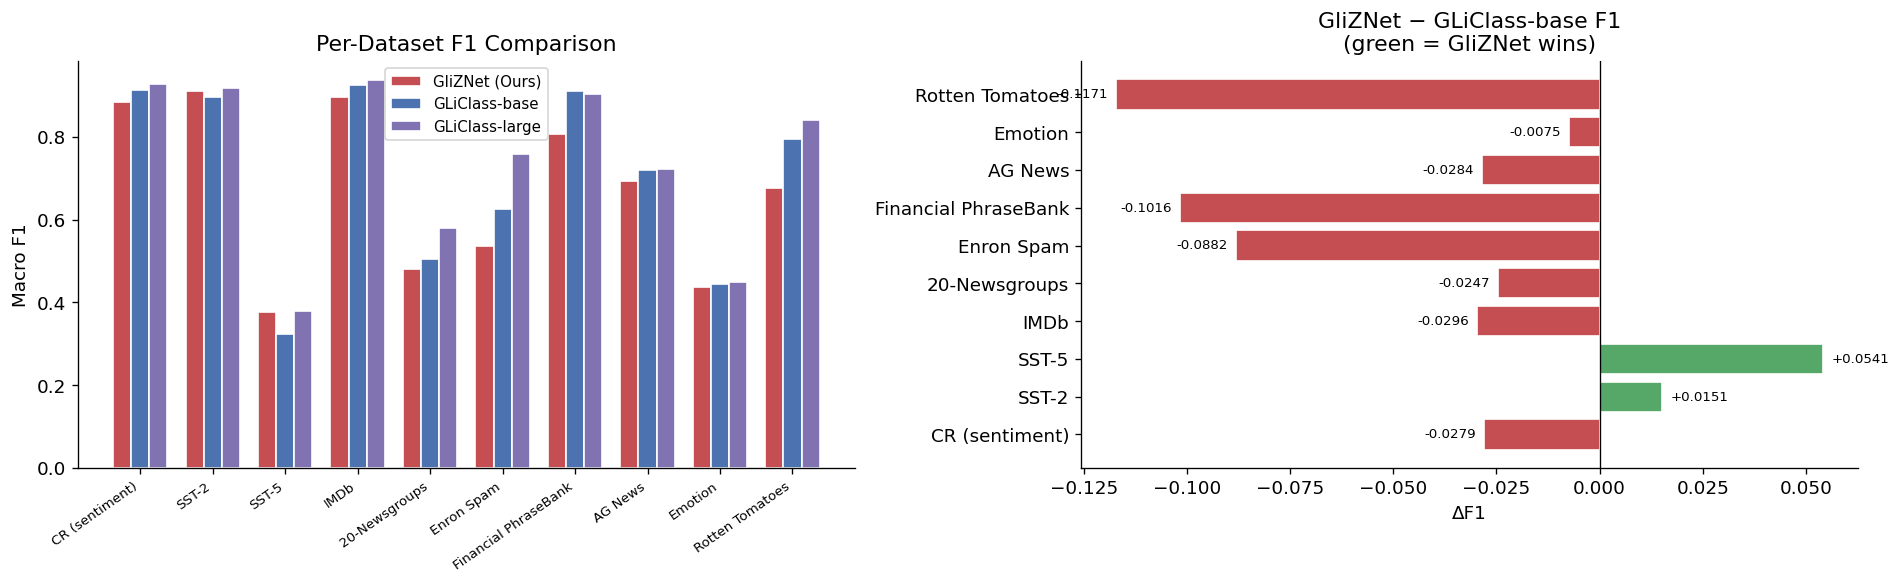

Datasets where GliZNet leads GLiClass-base:
dataset  delta_vs_base
  SST-2         0.0151
  SST-5         0.0541

Datasets where GliZNet trails:
             dataset  delta_vs_base
      CR (sentiment)        -0.0279
                IMDb        -0.0296
       20-Newsgroups        -0.0247
          Enron Spam        -0.0882
Financial PhraseBank        -0.1016
             AG News        -0.0284
             Emotion        -0.0075
     Rotten Tomatoes        -0.1171


In [22]:
per_dataset = pd.DataFrame({
    "dataset": ["CR (sentiment)", "SST-2", "SST-5", "IMDb", "20-Newsgroups",
                "Enron Spam", "Financial PhraseBank", "AG News", "Emotion", "Rotten Tomatoes"],
    "gliznet":       [0.8848, 0.9110, 0.3777, 0.8952, 0.4798, 0.5370, 0.8078, 0.6925, 0.4375, 0.6772],
    "gliclass_large":[0.9281, 0.9176, 0.3798, 0.9366, 0.5806, 0.7574, 0.9023, 0.7229, 0.4504, 0.8411],
    "gliclass_base": [0.9127, 0.8959, 0.3236, 0.9248, 0.5045, 0.6252, 0.9094, 0.7209, 0.4450, 0.7943],
})
per_dataset["delta_vs_base"] = per_dataset["gliznet"] - per_dataset["gliclass_base"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grouped bar chart
x = np.arange(len(per_dataset))
w = 0.25
axes[0].bar(x - w, per_dataset["gliznet"],        width=w, label="GliZNet (Ours)", color="#C44E52", edgecolor="white")
axes[0].bar(x,     per_dataset["gliclass_base"],  width=w, label="GLiClass-base",  color="#4C72B0", edgecolor="white")
axes[0].bar(x + w, per_dataset["gliclass_large"], width=w, label="GLiClass-large", color="#8172B2", edgecolor="white")
axes[0].set_xticks(x); axes[0].set_xticklabels(per_dataset["dataset"], rotation=35, ha="right", fontsize=8)
axes[0].set_ylabel("Macro F1"); axes[0].set_title("Per-Dataset F1 Comparison")
axes[0].legend(fontsize=9)

# Delta chart: GliZNet - GLiClass-base
colors_delta = ["#55A868" if d >= 0 else "#C44E52" for d in per_dataset["delta_vs_base"]]
axes[1].barh(per_dataset["dataset"], per_dataset["delta_vs_base"], color=colors_delta, edgecolor="white")
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("GliZNet − GLiClass-base F1\n(green = GliZNet wins)")
axes[1].set_xlabel("ΔF1")
for i, (_, row) in enumerate(per_dataset.iterrows()):
    d = row["delta_vs_base"]
    axes[1].text(d + (0.002 if d >= 0 else -0.002), i, f"{d:+.4f}",
                 va="center", ha="left" if d >= 0 else "right", fontsize=8)

plt.tight_layout(); plt.show()

print("Datasets where GliZNet leads GLiClass-base:")
print(per_dataset[per_dataset["delta_vs_base"] > 0][["dataset","delta_vs_base"]].to_string(index=False))
print("\nDatasets where GliZNet trails:")
print(per_dataset[per_dataset["delta_vs_base"] < 0][["dataset","delta_vs_base"]].to_string(index=False))

## 8. Data Efficiency Analysis (reproduces Discussion Section)

**Claim:** ZSHOT-HARDSET-v2 yields ~1.27× "effective examples" per F1 point relative to GLiClass's corpus.

GliZNet F1/example:           7.45e-07
GLiClass-base F1/example:     5.88e-07
Efficiency ratio:             1.27×  (paper claims ~1.27×)

GLiClass-base (linear extrap. to 900k examples): 0.5292
GliZNet actual at 900k:                          0.6701
GliZNet outperforms linear extrapolation by:     +0.1409 F1


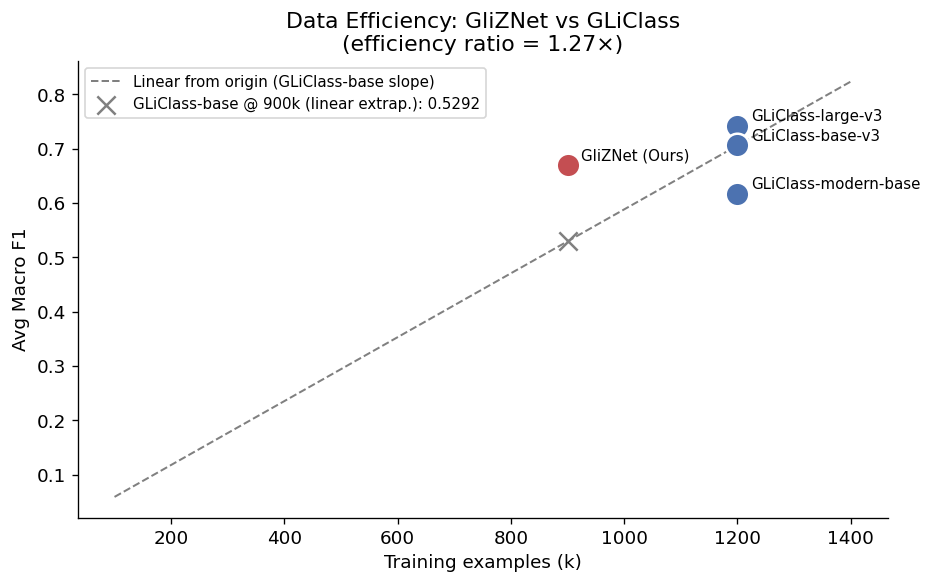

In [23]:
# Data efficiency: F1 per training example
gliznet_eff   = 0.6701 / 900_000   # F1 per example
base_eff      = 0.7056 / 1_200_000
efficiency_ratio = gliznet_eff / base_eff

# Hypothetical: if GLiClass-base had only 900k examples, predicted F1 under linear assumption
gliclass_at_900k = 0.7056 * (900_000 / 1_200_000)

print(f"GliZNet F1/example:           {gliznet_eff:.2e}")
print(f"GLiClass-base F1/example:     {base_eff:.2e}")
print(f"Efficiency ratio:             {efficiency_ratio:.2f}×  (paper claims ~1.27×)")
print(f"\nGLiClass-base (linear extrap. to 900k examples): {gliclass_at_900k:.4f}")
print(f"GliZNet actual at 900k:                          {0.6701:.4f}")
print(f"GliZNet outperforms linear extrapolation by:     {0.6701 - gliclass_at_900k:+.4f} F1")

fig, ax = plt.subplots(figsize=(8, 5))

# Plot all 4 models
for _, row in benchmark.iterrows():
    color = "#C44E52" if "Ours" in row["model"] else "#4C72B0"
    ax.scatter(row["train_k"], row["avg_f1"], s=200, color=color,
               edgecolors="white", lw=1.5, zorder=4)
    ax.annotate(row["model"], (row["train_k"], row["avg_f1"]),
                textcoords="offset points", xytext=(8, 3), fontsize=9)

# Linear trend through base & large (both GLiClass)
trend_x = np.linspace(100, 1400, 200)
# Use GLiClass-base and large to fit a line: (1200, 0.7056) and (1200, 0.7417) - same x → use different approach
# Better: show that GliZNet is above a naive linear interpolation from origin
m = 0.7056 / 1200  # slope anchored at origin
ax.plot(trend_x, m * trend_x, ls="--", color="gray", lw=1.2, label="Linear from origin (GLiClass-base slope)")
ax.scatter([900], [gliclass_at_900k], s=120, color="gray", marker="x", zorder=5,
           label=f"GLiClass-base @ 900k (linear extrap.): {gliclass_at_900k:.4f}")

ax.set_xlabel("Training examples (k)")
ax.set_ylabel("Avg Macro F1")
ax.set_title(f"Data Efficiency: GliZNet vs GLiClass\n(efficiency ratio = {efficiency_ratio:.2f}×)")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 9. Label Reuse & Role Distribution

How many times does the average label appear, and in what roles?  
A healthy training set needs labels that appear in **both** positive and negative contexts.

Average appearances per unique label: 1.58×
Labels in both roles (cross-role):    6,413  (14.6%)
Labels only positive:                 9,270  (21.1%)
Labels only negative:                 28,339  (64.4%)


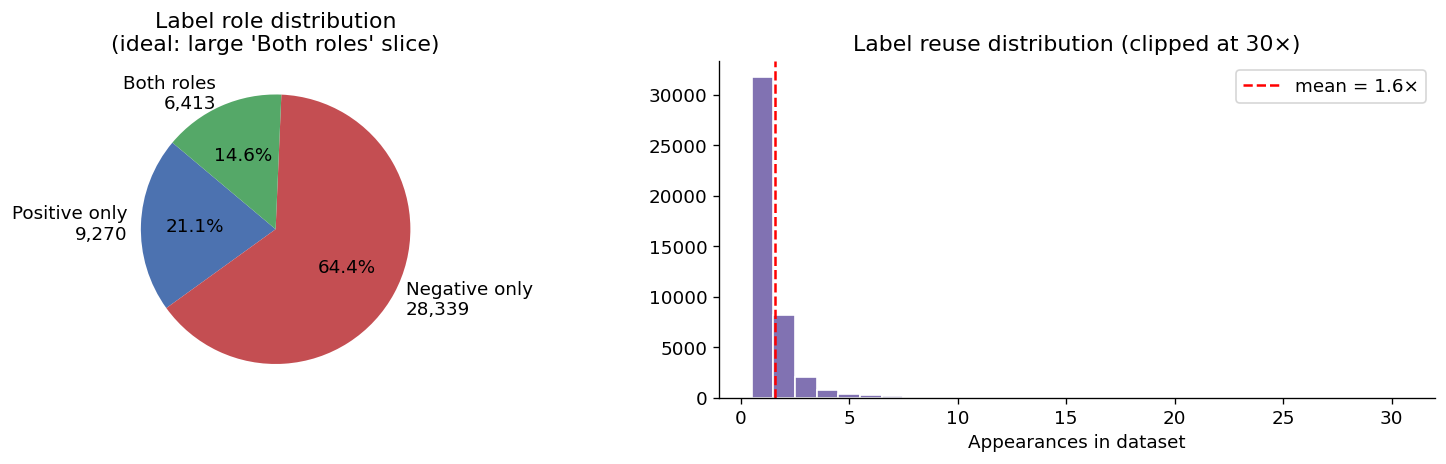

In [24]:
neg_counter = Counter(all_neg_flat)
cross_role  = set(pos_counter) & set(neg_counter)
only_pos    = set(pos_counter) - set(neg_counter)
only_neg    = set(neg_counter) - set(pos_counter)

reuse_counts = sorted(all_counter.values(), reverse=True)
avg_reuse = np.mean(reuse_counts)

print(f"Average appearances per unique label: {avg_reuse:.2f}×")
print(f"Labels in both roles (cross-role):    {len(cross_role):,}  ({100*len(cross_role)/unique_all:.1f}%)")
print(f"Labels only positive:                 {len(only_pos):,}  ({100*len(only_pos)/unique_all:.1f}%)")
print(f"Labels only negative:                 {len(only_neg):,}  ({100*len(only_neg)/unique_all:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pie: role distribution
pie_vals   = [len(only_pos), len(only_neg), len(cross_role)]
pie_labels = [f"Positive only\n{len(only_pos):,}", f"Negative only\n{len(only_neg):,}",
              f"Both roles\n{len(cross_role):,}"]
axes[0].pie(pie_vals, labels=pie_labels, colors=["#4C72B0","#C44E52","#55A868"],
            autopct="%1.1f%%", startangle=140)
axes[0].set_title("Label role distribution\n(ideal: large 'Both roles' slice)")

# Reuse histogram (clipped at 30)
clipped = [min(c, 30) for c in reuse_counts]
axes[1].hist(clipped, bins=range(1, 32), color="#8172B2", edgecolor="white", align="left")
axes[1].axvline(avg_reuse, color="red", ls="--", label=f"mean = {avg_reuse:.1f}×")
axes[1].set_title("Label reuse distribution (clipped at 30×)")
axes[1].set_xlabel("Appearances in dataset"); axes[1].legend()

plt.tight_layout(); plt.show()

## 10. Paper-Ready Summary Table

All key numbers from the notebook in one place, ready to paste back into the paper.

In [26]:
summary = [
    ("─── Dataset Scale ──────────────────────────────────────────",  "",           ""),
    ("Total examples (sample)",                   f"{n:,}",              "Table 3"),
    ("Unique positive label vocabulary",           f"{unique_pos:,}",     "Table 3"),
    ("Total unique labels (pos+neg)",              f"{unique_all:,}",     "Table 3"),
    ("─── Label Counts per Example ──────────────────────────────",  "",           ""),
    ("Mean positive labels / text",                f"{df['n_pos'].mean():.2f} ±{df['n_pos'].std():.2f}", "Table 4"),
    ("Mean negative labels / text",                f"{df['n_neg'].mean():.2f} ±{df['n_neg'].std():.2f}", "Table 4"),
    ("─── Cross-Role Constraint (global) ────────────────────────",  "",           ""),
    ("Labels in both roles (any freq)",            f"{len(both_roles):,}  ({pct_both:.1f}%)",  "Table 4"),
    ("→ Labels seen ≥2× in sample",               f"{len(freq2):,}",     "Table 4"),
    ("  → Of these, in both roles",               f"{len(both_freq2):,}  ({pct_both_freq2:.1f}%)", "Table 4"),
    ("Labels ONLY as positives",                   f"{len(only_pos):,}  ({pct_only_pos:.1f}%)", "Table 4"),
    ("Labels ONLY as negatives",                   f"{len(only_neg):,}  ({pct_only_neg:.1f}%)", "Table 4"),
    ("─── Label Depth ───────────────────────────────────────────",  "",           ""),
    ("Mean token overlap (ZSHOT labels)",          f"{np.mean(zshot_scores):.3f}", "Sec. 6.3"),
    ("Shallow labels ≥0.8 overlap (ZSHOT)",        f"{100*np.mean(np.array(zshot_scores)>=0.8):.1f}%", "Sec. 6.3"),
    ("Mean token overlap (Wikipedia baseline)",    f"{np.mean(baseline_scores):.3f}", "Sec. 6.3"),
    ("─── Data Efficiency ────────────────────────────────────────", "",           ""),
    ("GliZNet avg macro F1",                       "0.6701",              "Table 5"),
    ("GLiClass-base avg macro F1",                 "0.7056",              "Table 5"),
    ("GliZNet data efficiency ratio",              f"{efficiency_ratio:.2f}×", "Discussion"),
]

print(f"{'Metric':<52} {'Value':<22} {'Paper ref'}")
print("═" * 86)
for metric, value, ref in summary:
    if value == "":
        print(f"\n{metric}")
    else:
        print(f"  {metric:<50} {value:<22} {ref}")

Metric                                               Value                  Paper ref
══════════════════════════════════════════════════════════════════════════════════════

─── Dataset Scale ──────────────────────────────────────────
  Total examples (sample)                            5,000                  Table 3
  Unique positive label vocabulary                   15,683                 Table 3
  Total unique labels (pos+neg)                      44,022                 Table 3

─── Label Counts per Example ──────────────────────────────
  Mean positive labels / text                        3.80 ±0.64             Table 4
  Mean negative labels / text                        10.08 ±2.01            Table 4

─── Cross-Role Constraint (global) ────────────────────────
  Labels in both roles (any freq)                    6,413  (14.6%)         Table 4
  → Labels seen ≥2× in sample                        12,254                 Table 4
    → Of these, in both roles                        6,